In [1]:
!pip install -q ipywidgets
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  libxcomposite1 libxdot4
0 upgraded, 11 newly installed, 0 to remove and 90 not upgraded.
Need to get 2,478 kB of archives.
After this operation, 7,871 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main am

In [2]:
## -- System dependencies --
import sys, os, gc
import torch
import pydot
import tensorflow as tf

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

2026-06-10 05:25:28.996110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781069129.310217      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781069129.395003      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781069130.092801      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781069130.092873      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781069130.092877      16 computation_placer.cc:177] computation placer alr

ℹ️ Device: CPU 4 cores


In [3]:
# os.environ['KERAS_BACKEND'] = 'tensorflow'

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools
import shutil

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, brier_score_loss
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder, LabelEncoder

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

tf.get_logger().setLevel('ERROR')
warnings.filterwarnings("ignore", message="Setting the random state for TF")

In [5]:
## -- Global Settings --
sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style('whitegrid')
# plt.style.use("ggplot")

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

tf.keras.utils.set_random_seed(CFG['SEED'])

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e6 | Stellar Class/_stellar_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'star_classification.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [7]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 48.5+ MB


In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.999810
delta,577347.0,21.834654,18.933570,-17.966988,2.474097,21.484412,36.988310,79.158322
u,577347.0,22.441926,2.018135,-0.139225,20.977090,22.570222,23.869103,28.253263
g,577347.0,21.007273,1.795426,13.535483,19.865005,21.467820,22.292715,27.620208
r,577347.0,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,19.378911,1.580059,11.962781,18.306820,19.631642,20.608191,27.910853
z,577347.0,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,0.723135,0.810070,-0.009970,0.181052,0.497525,0.881390,7.010780
class,577347.0,0.489465,0.732431,0.000000,0.000000,0.000000,1.000000,2.000000


In [9]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig.g, orig.r)
orig['galaxy_population'] = galaxy_population(orig.u, orig.r)

orig

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,0,0.000000,9374,57749,438,M,Blue_Cloud
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,0,0.404895,7626,56934,866,M,Red_Sequence
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,0,0.143366,2764,54535,74,M,Red_Sequence
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,0,0.455040,6751,56368,470,M,Red_Sequence


In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Original,99999,99999,93748,92651,91901,92019,92007,99295,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


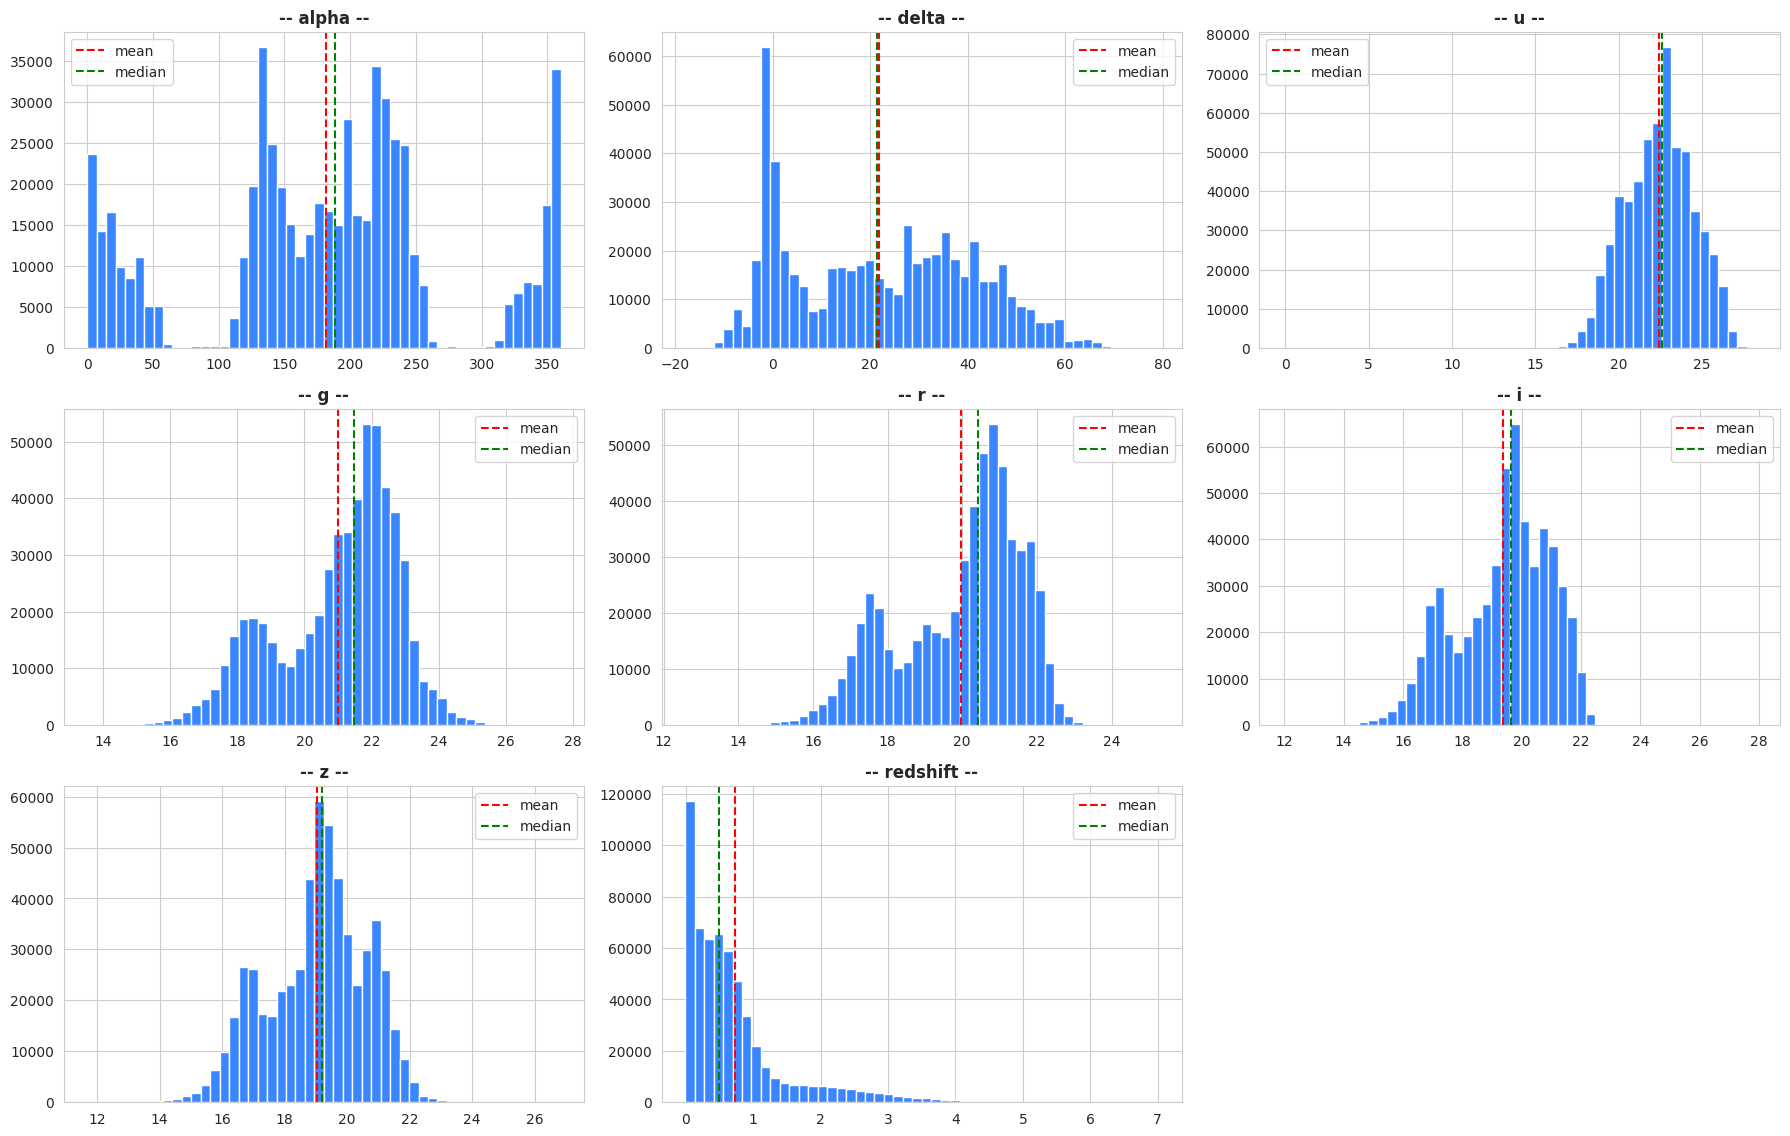

In [11]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'-- {col} --', fontweight='semibold')
    plt.legend()

plt.tight_layout()
plt.show()

## FEATURE ENGINEERING

In [12]:
def get_class_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> {label: weight}
    """
    if opt != 'auto':
        return opt
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        class_weights = dict(zip(cls_, wts_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [13]:
## -- Extractions & Binnig --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []
 
round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# for col in ['redshift']:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 6):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(1):
#     #     d_n = f'{col}_{d}_digit_'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nQuantile binning... ", end='')
#     for q in [4]:
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [15]:
for col in ['delta', 'alpha']: # 'u', 'g', 'r', 'i', 'z',
    # print(f"\nRounding... ", end='')
    # for r in range(-3, 5):
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)
    
    # print(f"\nExtracting digits... ", end='')
    # for d in range(-3, 6):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [100]: # 50, 100, 400
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)
        
    print(f"\nQuantile binning.. ", end='')
    for q in [100]: 
        q_n = f'{col}_qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")


Quantile binning.. delta_qbin_100, 
Quantile binning.. alpha_qbin_100, 
✅ ROUNDS: 0
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 2


In [16]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


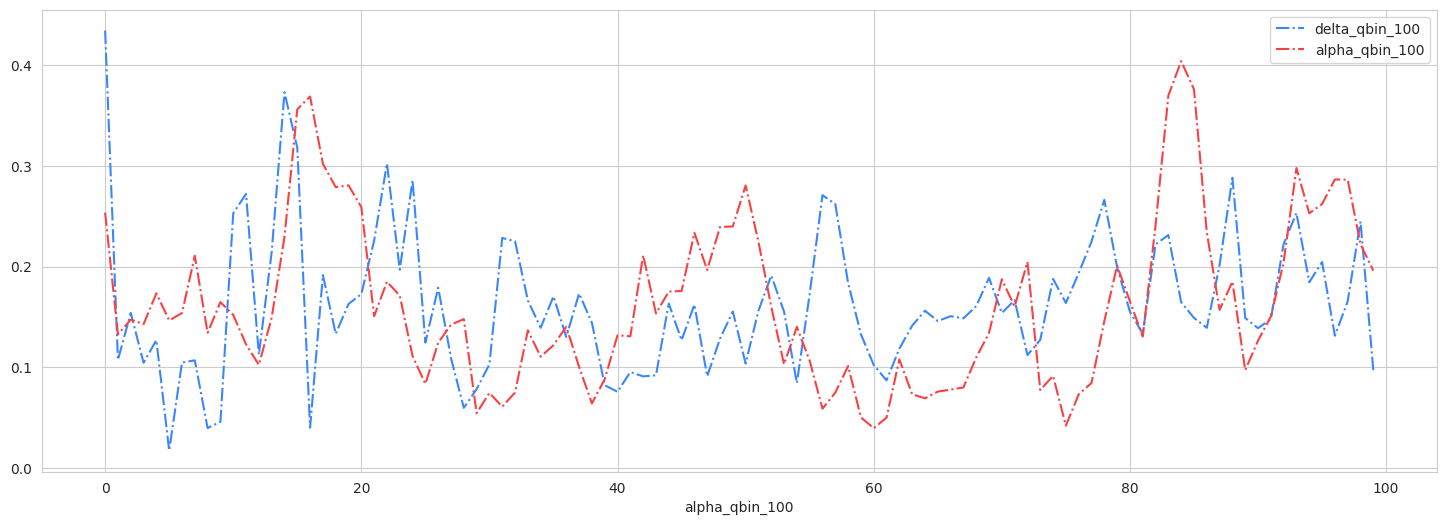

In [17]:
plt.figure(figsize=(18, 6))
ax = (train.groupby(by=Q_BINS[0])[TARGET].mean() / 3).plot(linestyle='-.', label=Q_BINS[0])
(train.groupby(by=Q_BINS[1])[TARGET].mean() / 3).plot(linestyle='-.', ax=ax, label=Q_BINS[1])

plt.legend()
plt.show()

In [18]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [19]:
# # 2. Calculate fundamental colors
# train['g_r'] = train['g'] - train['r']
# train['r_i'] = train['r'] - train['i']

# # 3. Calculate Euclidean Distance from the known Astrophysical Loci
# # The stellar locus is generally centered around g-r ~ 0.52 and r-i ~ 0.25
# train['stellar_locus_dist'] = np.sqrt((train['g_r'] - 0.52)**2 + (train['r_i'] - 0.25)**2)

# # Quasars tend to scatter around a different locus (g-r ~ 0.24, r-i ~ 0.15)
# train['qso_locus_dist'] = np.sqrt((train['g_r'] - 0.24)**2 + (train['r_i'] - 0.15)**2)

# print("Features successfully engineered!")

#### This table makes the creation of Color Indices `(u - g, g - r, r - i, i - z)` mandatory.

In [20]:
## -- Arithmetic interaction --
# u - g, g - r, r - i, i - z

# ('u', 'g'),
# ('g', 'r'),
# ('g', 'i'),
# ('i', 'z'),
# ('r', 'z')

for df in tqdm([train, test, orig]):
    df['u_g_sub_'] = df['u'] - df['g']
    df['g_r_sub_'] = df['g'] - df['r']

    df['g_i_sub_'] = df['g'] - df['i']
    df['r_z_sub_'] = df['r'] - df['z']

    df['i_z_sub_'] = df['i'] - df['z']
    df['r_i_sub_'] = df['r'] - df['i']
    
    df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

    for band in ['g', 'i']:
        b_col = f"_{band}_redshift_div_"
        df[b_col] = df[band] / (df['redshift'] + 1e-6)

color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
color_bands.append('stellar_locus_dist')

train[color_bands].describe()

  0%|          | 0/3 [00:00<?, ?it/s]

,u_g_sub_,g_r_sub_,g_i_sub_,r_z_sub_,i_z_sub_,r_i_sub_,_g_redshift_div_,_i_redshift_div_,stellar_locus_dist
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,5.773470e+05,5.773470e+05,577347.000000
mean,1.434652,1.044463,1.628362,0.921675,0.337775,0.583900,9.081604e+02,8.735087e+02,0.940107
std,1.142003,0.736291,1.073617,0.675999,0.395797,0.496787,2.578451e+05,2.542172e+05,0.540065
min,-23.155858,-8.104372,-10.807923,-14.008533,-14.210769,-10.757964,-1.719873e+08,-1.713189e+08,0.001131
25%,0.598523,0.419982,0.634816,0.412939,0.094029,0.215544,2.422425e+01,2.196961e+01,0.478341
50%,1.333334,1.075605,1.681938,0.913850,0.343779,0.570048,4.149269e+01,3.716272e+01,0.878239
75%,2.087557,1.646067,2.551026,1.412064,0.590450,0.946885,9.989013e+01,9.107308e+01,1.367064
max,7.523080,8.874428,9.284916,9.492911,7.624849,8.749329,3.962015e+07,3.559959e+07,12.108608


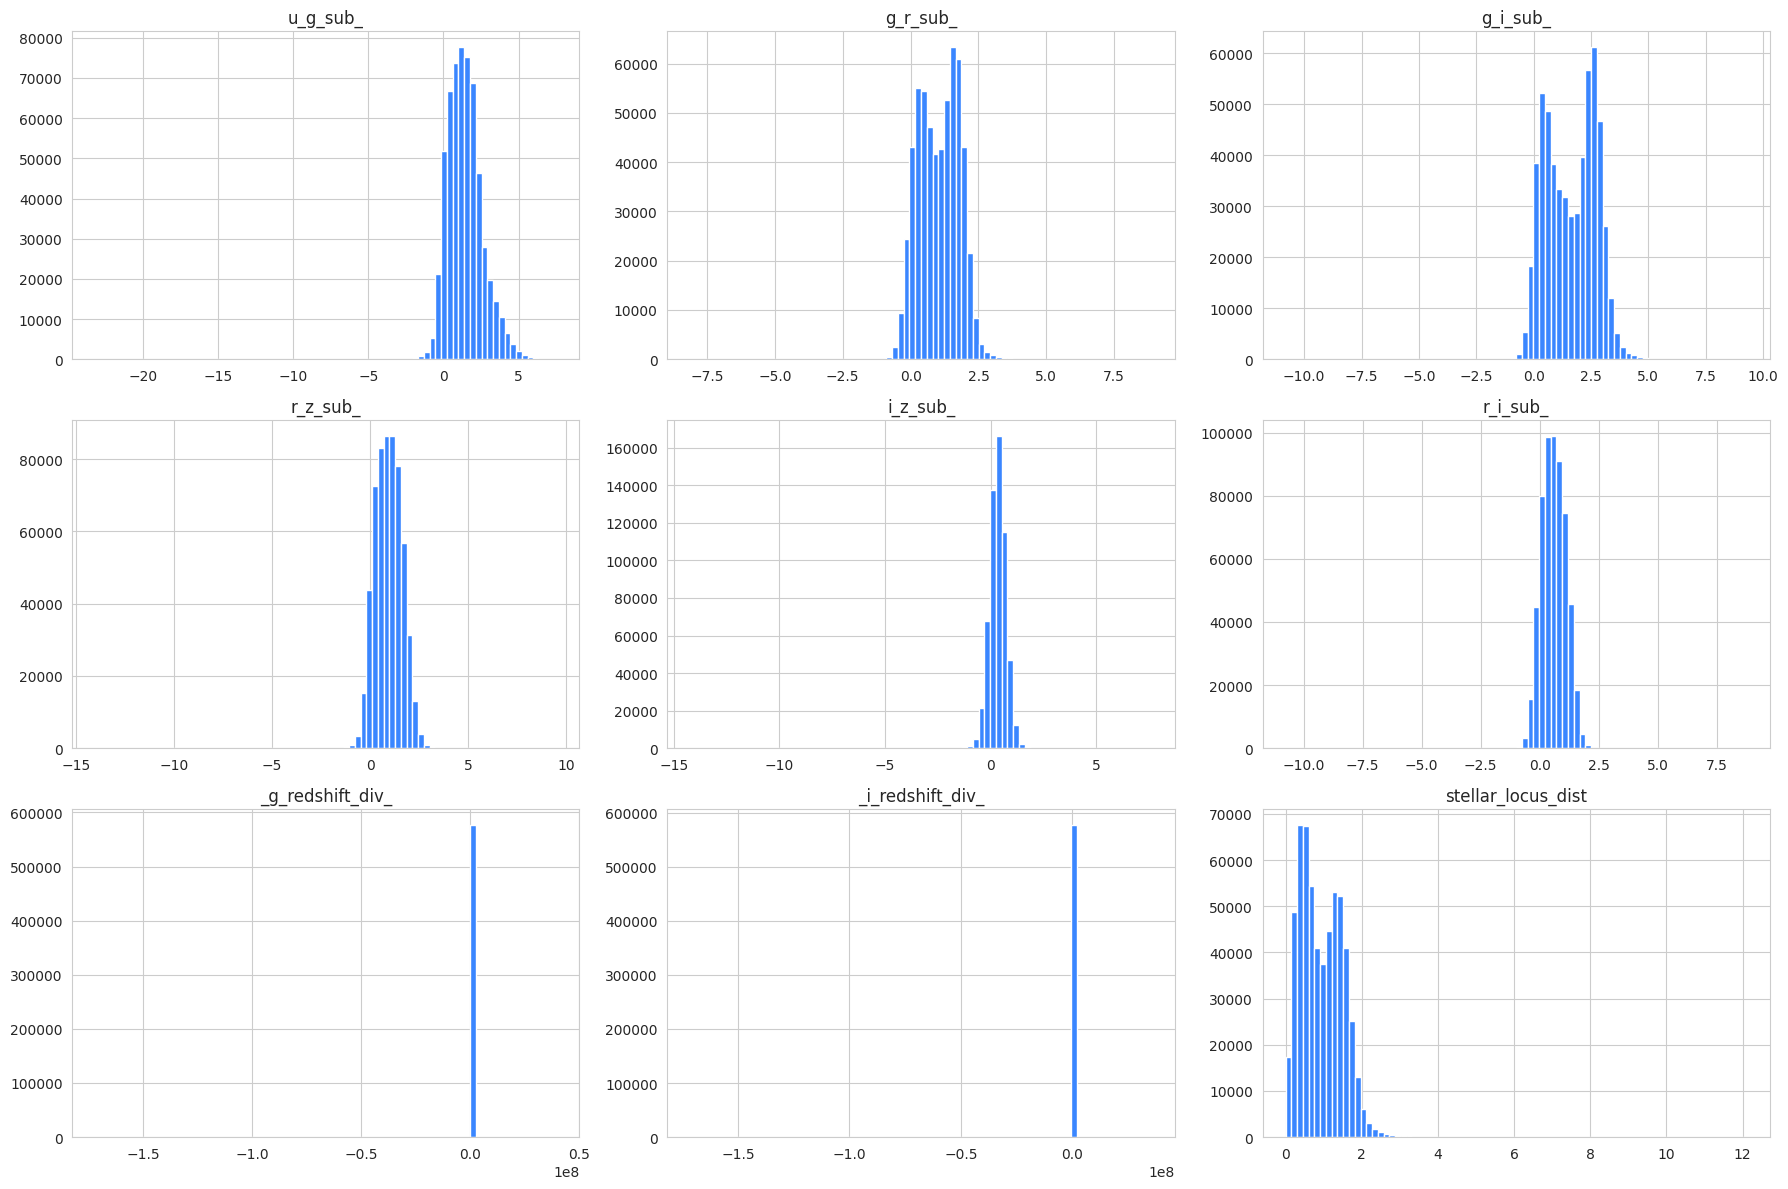

In [21]:
train[color_bands].hist(bins=80, figsize=(18, 12))
plt.tight_layout()
plt.show()

In [22]:
## -- Cyclic encoding --

for df in [train, test, orig]:
    for col in ['alpha']:
        for p in [180, 360]:
            df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
            df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

for df in [train, test, orig]:
    for col in ['delta']:
        for p in [180]:
            df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
            df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

train[cyclic_cols].head()

,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_
0,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832
1,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461
2,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684
3,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274
4,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586


In [23]:
# plt.figure(figsize=(18, 15))
# sns.heatmap(train[].corr(), annot=True) # cyclic_cols+color_bands
# plt.show()

In [24]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [25]:
INTER = []

for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    print(f"Paired: {n_col}... ", end='')
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print()
print(f"Total interaction features: {len(INTER)}")

train[INTER].head()

Pairwise:   0%|          | 0/1 [00:00<?, ?it/s]

Paired: Bi_spectral_type-|-galaxy_population... 
Total interaction features: 1


,Bi_spectral_type-|-galaxy_population
0,M_Red_Sequence
1,M_Red_Sequence
2,O/B_Blue_Cloud
3,M_Red_Sequence
4,M_Red_Sequence


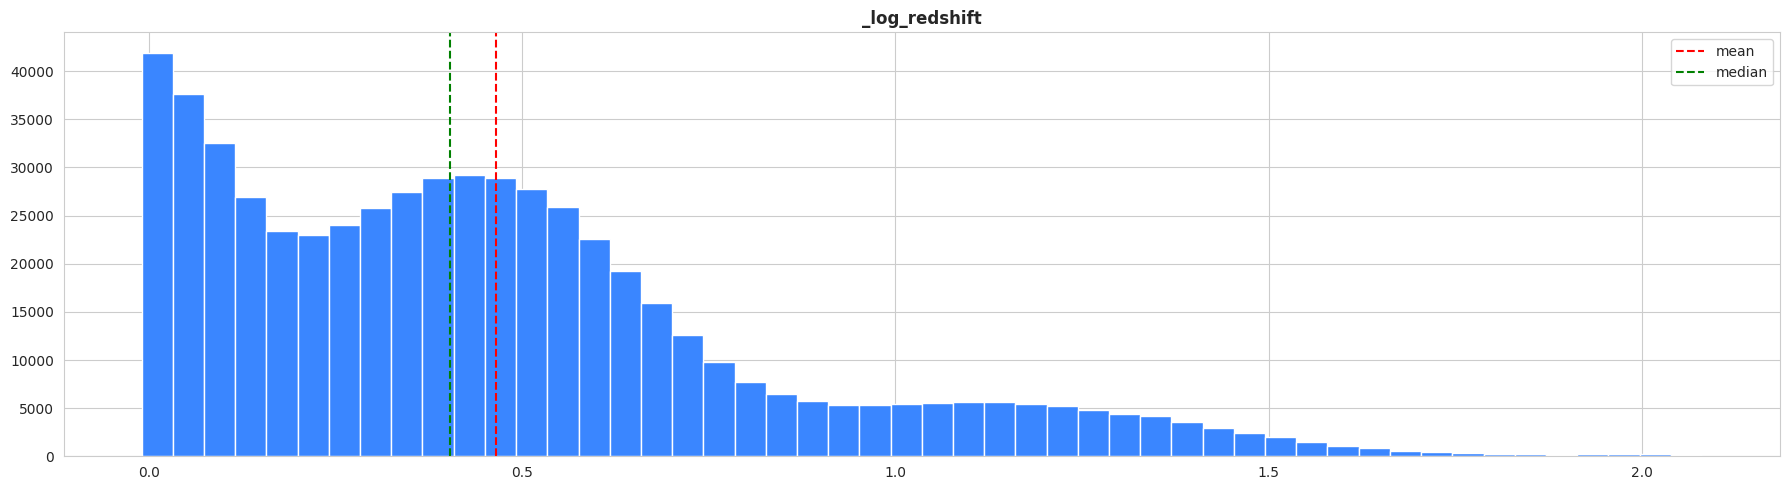

In [26]:
## -- Create log-transformed features --
for df in [train, test, orig]:
    for col in ['redshift',]:
        n_log = f"_log_{col}"
        df[n_log] = np.log1p(df[col])

log_cols = [c for c in train.columns if c.startswith('_log_')]

plt.figure(figsize=(18, 5))
for i, col in enumerate(log_cols):
    # plt.subplot(2, len(log_cols)//2, i+1)
    plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'{col}', fontweight='semibold')
    plt.legend()

plt.tight_layout()
plt.show()

In [27]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the
#         global mean. If 'auto', an empirical Bayes estimate is used.

#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping

#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)

#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]

#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'

#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)

#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()

#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups

#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)

#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [28]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [29]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+ROUNDS+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [30]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in BASE:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [31]:
## -- Factorize using combined data --
for c in ['galaxy_population']: # CATS
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)].astype('float')
    test[c]  = combine[len(train):len(train)+len(test)].astype('float')
    orig[c]  = combine[-len(orig):].astype('float')

print('Label encoding complete!')

Label encoding complete!


In [32]:
## -- Ohe-Hot encode CATS --
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]

combine = pd.concat([train[FEATURES], test[FEATURES]])
combine_ohe = pd.get_dummies(combine, columns=['spectral_type']+INTER+Q_BINS, dtype='float', drop_first=False)

train_enc = combine_ohe[:len(train)]
train = pd.concat([train_enc, train[TARGET]], axis=1)
test = combine_ohe[len(train):]

del combine_ohe

print(f'One-Hot Encoding complete!\nExpanded Features: {test.shape[1]}')
train.head()

One-Hot Encoding complete!
Expanded Features: 237


,alpha,delta,u,g,r,i,z,redshift,galaxy_population,u_g_sub_,g_r_sub_,g_i_sub_,r_z_sub_,i_z_sub_,r_i_sub_,stellar_locus_dist,_g_redshift_div_,_i_redshift_div_,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_,_log_redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,Bi_spectral_type-|-galaxy_population_A/F_Blue_Cloud,Bi_spectral_type-|-galaxy_population_A/F_Red_Sequence,Bi_spectral_type-|-galaxy_population_G/K_Blue_Cloud,Bi_spectral_type-|-galaxy_population_G/K_Red_Sequence,Bi_spectral_type-|-galaxy_population_M_Blue_Cloud,Bi_spectral_type-|-galaxy_population_M_Red_Sequence,Bi_spectral_type-|-galaxy_population_O/B_Blue_Cloud,Bi_spectral_type-|-galaxy_population_O/B_Red_Sequence,delta_qbin_100_0.0,delta_qbin_100_1.0,delta_qbin_100_2.0,delta_qbin_100_3.0,delta_qbin_100_4.0,delta_qbin_100_5.0,delta_qbin_100_6.0,delta_qbin_100_7.0,delta_qbin_100_8.0,delta_qbin_100_9.0,delta_qbin_100_10.0,delta_qbin_100_11.0,delta_qbin_100_12.0,delta_qbin_100_13.0,delta_qbin_100_14.0,delta_qbin_100_15.0,delta_qbin_100_16.0,delta_qbin_100_17.0,delta_qbin_100_18.0,delta_qbin_100_19.0,delta_qbin_100_20.0,delta_qbin_100_21.0,delta_qbin_100_22.0,delta_qbin_100_23.0,delta_qbin_100_24.0,delta_qbin_100_25.0,delta_qbin_100_26.0,delta_qbin_100_27.0,delta_qbin_100_28.0,delta_qbin_100_29.0,delta_qbin_100_30.0,delta_qbin_100_31.0,delta_qbin_100_32.0,delta_qbin_100_33.0,delta_qbin_100_34.0,delta_qbin_100_35.0,delta_qbin_100_36.0,delta_qbin_100_37.0,delta_qbin_100_38.0,delta_qbin_100_39.0,delta_qbin_100_40.0,delta_qbin_100_41.0,delta_qbin_100_42.0,delta_qbin_100_43.0,delta_qbin_100_44.0,delta_qbin_100_45.0,delta_qbin_100_46.0,delta_qbin_100_47.0,delta_qbin_100_48.0,delta_qbin_100_49.0,delta_qbin_100_50.0,delta_qbin_100_51.0,delta_qbin_100_52.0,delta_qbin_100_53.0,delta_qbin_100_54.0,delta_qbin_100_55.0,delta_qbin_100_56.0,delta_qbin_100_57.0,delta_qbin_100_58.0,delta_qbin_100_59.0,delta_qbin_100_60.0,delta_qbin_100_61.0,delta_qbin_100_62.0,delta_qbin_100_63.0,delta_qbin_100_64.0,delta_qbin_100_65.0,delta_qbin_100_66.0,delta_qbin_100_67.0,delta_qbin_100_68.0,delta_qbin_100_69.0,delta_qbin_100_70.0,delta_qbin_100_71.0,delta_qbin_100_72.0,delta_qbin_100_73.0,delta_qbin_100_74.0,delta_qbin_100_75.0,delta_qbin_100_76.0,delta_qbin_100_77.0,delta_qbin_100_78.0,delta_qbin_100_79.0,delta_qbin_100_80.0,delta_qbin_100_81.0,delta_qbin_100_82.0,delta_qbin_100_83.0,delta_qbin_100_84.0,delta_qbin_100_85.0,delta_qbin_100_86.0,delta_qbin_100_87.0,delta_qbin_100_88.0,delta_qbin_100_89.0,delta_qbin_100_90.0,delta_qbin_100_91.0,delta_qbin_100_92.0,delta_qbin_100_93.0,delta_qbin_100_94.0,delta_qbin_100_95.0,delta_qbin_100_96.0,delta_qbin_100_97.0,delta_qbin_100_98.0,delta_qbin_100_99.0,alpha_qbin_100_0.0,alpha_qbin_100_1.0,alpha_qbin_100_2.0,alpha_qbin_100_3.0,alpha_qbin_100_4.0,alpha_qbin_100_5.0,alpha_qbin_100_6.0,alpha_qbin_100_7.0,alpha_qbin_100_8.0,alpha_qbin_100_9.0,alpha_qbin_100_10.0,alpha_qbin_100_11.0,alpha_qbin_100_12.0,alpha_qbin_100_13.0,alpha_qbin_100_14.0,alpha_qbin_100_15.0,alpha_qbin_100_16.0,alpha_qbin_100_17.0,alpha_qbin_100_18.0,alpha_qbin_100_19.0,alpha_qbin_100_20.0,alpha_qbin_100_21.0,alpha_qbin_100_22.0,alpha_qbin_100_23.0,alpha_qbin_100_24.0,alpha_qbin_100_25.0,alpha_qbin_100_26.0,alpha_qbin_100_27.0,alpha_qbin_100_28.0,alpha_qbin_100_29.0,alpha_qbin_100_30.0,alpha_qbin_100_31.0,alpha_qbin_100_32.0,alpha_qbin_100_33.0,alpha_qbin_100_34.0,alpha_qbin_100_35.0,alpha_qbin_100_36.0,alpha_qbin_100_37.0,alpha_qbin_100_38.0,alpha_qbin_100_39.0,alpha_qbin_100_40.0,alpha_qbin_100_41.0,alpha_qbin_100_42.0,alpha_qbin_100_43.0,alpha_qbin_100_44.0,alpha_qbin_100_45.0,alpha_qbin_100_46.0,alpha_qbin_100_47.0,alpha_qbin_100_48.0,alpha_qbin_100_49.0,alpha_qbin_100_50.0,alpha_qbin_100_51.0,alpha_qbin_100_52.0,alpha_qbin_100_53.0,alpha_qbin_100_54.0,alpha_qbin_100_55.0,alpha_qbin_100_56.0,alpha_qbin_100_57.0,alpha_qbin_100_58.0,alpha_qbin_100_59.0,alpha_qbin_100_60.0,alpha_qbin_100_61.0,alpha_qbin_100_62.0,alpha_qbi

In [33]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 237


,alpha,delta,u,g,r,i,z,redshift,galaxy_population,u_g_sub_,g_r_sub_,g_i_sub_,r_z_sub_,i_z_sub_,r_i_sub_,stellar_locus_dist,_g_redshift_div_,_i_redshift_div_,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_,_log_redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,Bi_spectral_type-|-galaxy_population_A/F_Blue_Cloud,Bi_spectral_type-|-galaxy_population_A/F_Red_Sequence,Bi_spectral_type-|-galaxy_population_G/K_Blue_Cloud,Bi_spectral_type-|-galaxy_population_G/K_Red_Sequence,Bi_spectral_type-|-galaxy_population_M_Blue_Cloud,Bi_spectral_type-|-galaxy_population_M_Red_Sequence,Bi_spectral_type-|-galaxy_population_O/B_Blue_Cloud,Bi_spectral_type-|-galaxy_population_O/B_Red_Sequence,delta_qbin_100_0.0,delta_qbin_100_1.0,delta_qbin_100_2.0,delta_qbin_100_3.0,delta_qbin_100_4.0,delta_qbin_100_5.0,delta_qbin_100_6.0,delta_qbin_100_7.0,delta_qbin_100_8.0,delta_qbin_100_9.0,delta_qbin_100_10.0,delta_qbin_100_11.0,delta_qbin_100_12.0,delta_qbin_100_13.0,delta_qbin_100_14.0,delta_qbin_100_15.0,delta_qbin_100_16.0,delta_qbin_100_17.0,delta_qbin_100_18.0,delta_qbin_100_19.0,delta_qbin_100_20.0,delta_qbin_100_21.0,delta_qbin_100_22.0,delta_qbin_100_23.0,delta_qbin_100_24.0,delta_qbin_100_25.0,delta_qbin_100_26.0,delta_qbin_100_27.0,delta_qbin_100_28.0,delta_qbin_100_29.0,delta_qbin_100_30.0,delta_qbin_100_31.0,delta_qbin_100_32.0,delta_qbin_100_33.0,delta_qbin_100_34.0,delta_qbin_100_35.0,delta_qbin_100_36.0,delta_qbin_100_37.0,delta_qbin_100_38.0,delta_qbin_100_39.0,delta_qbin_100_40.0,delta_qbin_100_41.0,delta_qbin_100_42.0,delta_qbin_100_43.0,delta_qbin_100_44.0,delta_qbin_100_45.0,delta_qbin_100_46.0,delta_qbin_100_47.0,delta_qbin_100_48.0,delta_qbin_100_49.0,delta_qbin_100_50.0,delta_qbin_100_51.0,delta_qbin_100_52.0,delta_qbin_100_53.0,delta_qbin_100_54.0,delta_qbin_100_55.0,delta_qbin_100_56.0,delta_qbin_100_57.0,delta_qbin_100_58.0,delta_qbin_100_59.0,delta_qbin_100_60.0,delta_qbin_100_61.0,delta_qbin_100_62.0,delta_qbin_100_63.0,delta_qbin_100_64.0,delta_qbin_100_65.0,delta_qbin_100_66.0,delta_qbin_100_67.0,delta_qbin_100_68.0,delta_qbin_100_69.0,delta_qbin_100_70.0,delta_qbin_100_71.0,delta_qbin_100_72.0,delta_qbin_100_73.0,delta_qbin_100_74.0,delta_qbin_100_75.0,delta_qbin_100_76.0,delta_qbin_100_77.0,delta_qbin_100_78.0,delta_qbin_100_79.0,delta_qbin_100_80.0,delta_qbin_100_81.0,delta_qbin_100_82.0,delta_qbin_100_83.0,delta_qbin_100_84.0,delta_qbin_100_85.0,delta_qbin_100_86.0,delta_qbin_100_87.0,delta_qbin_100_88.0,delta_qbin_100_89.0,delta_qbin_100_90.0,delta_qbin_100_91.0,delta_qbin_100_92.0,delta_qbin_100_93.0,delta_qbin_100_94.0,delta_qbin_100_95.0,delta_qbin_100_96.0,delta_qbin_100_97.0,delta_qbin_100_98.0,delta_qbin_100_99.0,alpha_qbin_100_0.0,alpha_qbin_100_1.0,alpha_qbin_100_2.0,alpha_qbin_100_3.0,alpha_qbin_100_4.0,alpha_qbin_100_5.0,alpha_qbin_100_6.0,alpha_qbin_100_7.0,alpha_qbin_100_8.0,alpha_qbin_100_9.0,alpha_qbin_100_10.0,alpha_qbin_100_11.0,alpha_qbin_100_12.0,alpha_qbin_100_13.0,alpha_qbin_100_14.0,alpha_qbin_100_15.0,alpha_qbin_100_16.0,alpha_qbin_100_17.0,alpha_qbin_100_18.0,alpha_qbin_100_19.0,alpha_qbin_100_20.0,alpha_qbin_100_21.0,alpha_qbin_100_22.0,alpha_qbin_100_23.0,alpha_qbin_100_24.0,alpha_qbin_100_25.0,alpha_qbin_100_26.0,alpha_qbin_100_27.0,alpha_qbin_100_28.0,alpha_qbin_100_29.0,alpha_qbin_100_30.0,alpha_qbin_100_31.0,alpha_qbin_100_32.0,alpha_qbin_100_33.0,alpha_qbin_100_34.0,alpha_qbin_100_35.0,alpha_qbin_100_36.0,alpha_qbin_100_37.0,alpha_qbin_100_38.0,alpha_qbin_100_39.0,alpha_qbin_100_40.0,alpha_qbin_100_41.0,alpha_qbin_100_42.0,alpha_qbin_100_43.0,alpha_qbin_100_44.0,alpha_qbin_100_45.0,alpha_qbin_100_46.0,alpha_qbin_100_47.0,alpha_qbin_100_48.0,alpha_qbin_100_49.0,alpha_qbin_100_50.0,alpha_qbin_100_51.0,alpha_qbin_100_52.0,alpha_qbin_100_53.0,alpha_qbin_100_54.0,alpha_qbin_100_55.0,alpha_qbin_100_56.0,alpha_qbin_100_57.0,alpha_qbin_100_58.0,alpha_qbin_100_59.0,alpha_qbin_100_60.0,alpha_qbin_100_61.0,alpha_qbin_100_62.0,alpha_qbi

In [34]:
# plt.figure(figsize=(18, 15))
# sns.heatmap(train.corr('spearman'), annot=True, fmt='.2f', cbar=False, center=0)
# plt.show()

In [35]:
# ## -- Ohe-Hot encode DIGITS --
# FEATURES = [c for c in train.columns if c not in ['id', TARGET]]

# combine = pd.concat([train[FEATURES], test[FEATURES]])
# combine_ohe = pd.get_dummies(combine, columns=DIGITS, dtype='int8', drop_first=False)

# train_enc = combine_ohe[:len(train)]
# test = combine_ohe[len(train):]

# train = pd.concat([train_enc, train[TARGET]], axis=1)

# print(f'One-Hot Encoding complete!\nExpanded Features: {combine_ohe.shape[1]}')
# combine_ohe.head(3)

In [36]:
# FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
# NEW_CATS = [c for c in FEATURES if col.endswith('_')]
# NEW_NUMS = [c for c in FEATURES if col.startswith('_')]

# print('Total Features:', len(FEATURES))
# print('Total Cat Cols:', len(NEW_CATS))
# print('Total Num Cols:', len(NEW_NUMS))

# train.head(3)

In [37]:
for col in FEATURES:
    if train[col].nunique() == 1:
        print(col)

In [38]:
def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED'])

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

# ML TRAINING

In [39]:
try:
    from scikeras.wrappers import KerasClassifier
except:
    %pip install -q -U scikeras
    from scikeras.wrappers import KerasClassifier

Note: you may need to restart the kernel to use updated packages.


In [40]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

try:
    import skrub
except:
    %pip install -q skrub
    import skrub

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.4/537.4 kB 8.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [41]:
def build_keras_model(shape, lr, drop, units):
    kernel_reg = tf.keras.regularizers.L2(0.0)
    use_bias   = True

    # 2. Create the Sequential model
    model = tf.keras.Sequential([
        tf.keras.Input(shape=shape),
        # Optional: Add BN here if your data isn't pre-scaled
        # tf.keras.layers.BatchNormalization(),

        ## -- 1st Layer --
        tf.keras.layers.Dense(units[0], 'relu', use_bias=use_bias,
                           kernel_regularizer=kernel_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- 2nd Layer --
        tf.keras.layers.Dense(units[1], 'relu', use_bias=use_bias,
                           kernel_regularizer=kernel_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- 3rd Layer --
        tf.keras.layers.Dense(units[2], 'relu', use_bias=use_bias,
                           kernel_regularizer=kernel_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- Output --
        tf.keras.layers.Dense(len(mapping), activation='softmax')
    ])

    model.compile(
        # optimizer=tf.keras.optimizers.RMSprop(lr),
        optimizer=tf.keras.optimizers.Adam(lr, weight_decay=None),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(name='loss'),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
        )

    return model

print('⚙️ Keras model ready ⚙️')

⚙️ Keras model ready ⚙️


In [42]:
## -- DEFINE TRAINER --
class TrainerCV:
    def __init__(
        self,
        model_builder, # function(input_shape, batch_size, epochs, learning_rate, **kwargs) -> tf.keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kf, # e.g., StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        batch_size: int=32,
        units=[256, 128, 32],
        epochs: int=10,
        patience: int=3,
        activation: str='relu',
        learning_rate: float=1e-2,
        dropout: float=0.3,
        eval_metric: str='val_loss',
        calibrator: str=None,
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kf = kf
        self.batch_size = batch_size
        self.units = units
        self.epochs = epochs
        self.patience = patience
        self.activation = activation
        self.learning_rate = learning_rate
        self.dropout = dropout
        self.eval_metric = eval_metric
        self.calibrator = calibrator

        self.result = None

    # def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
    #     # This helper can be extended if you want to apply masks or augmentation.
    #     return X, y

    # def _df_to_ds(self, df_full, target, batch_input):
    #     df = df_full.copy()
    #     labels = df.pop(target)
    #     ds = tensorflow.data.Dataset.from_tensor_slices((dict(df), labels))
    #     ds = ds.batch(batch_input)
    #     return ds


    def fit(self):
        train_df = self.train_df
        test_df  = self.test_df
        features = self.features
        target   = self.target

        print(f"\n========== Starting Cross-Validation for {self.model_name} ==========")
        start = time()

        num_classes = train_df[target].nunique()

        X = train_df[features]
        y = train_df[target]

        self.oof_preds  = np.zeros((len(train_df), num_classes))
        self.test_preds = np.zeros((len(test_df), num_classes))
        self.oof_scores = []

        self.calib_oof_preds   = np.zeros((len(train_df), num_classes))
        self.calib_test_preds  = np.zeros((len(test_df), num_classes))
        self.calib_fold_scores = []

        self.fold_histories = []

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        for idx, (train_idx, val_idx) in enumerate(self.kf.split(X, y)):
            print(f"\n***** FOLD {idx+1}/{self.kf.n_splits} *****")

            ## -- Split data for the current fold --
            X_train = train_df[features].iloc[train_idx]
            y_train = train_df[target].iloc[train_idx]
            X_valid = train_df[features].iloc[val_idx]
            y_valid = train_df[target].iloc[val_idx]

            X_test  = test_df[features].copy()

            # ## -- Target Encoding -- 
            # te_cols = INTER
            # print(f" • Target Encoding {len(te_cols)} features... ")
            # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

            ## -- Standardize Numerics --
            scale_cols = NUMS + color_bands
            for col in scale_cols:
                scaler = StandardScaler()
                X_train[col] = scaler.fit_transform(X_train[[col]])
                X_valid[col] = scaler.transform(X_valid[[col]])
                X_test[col]  = scaler.transform(X_test[[col]])

            ## -- Internal Split for Calibration --
            X_base, X_calib, y_base, y_calib = train_test_split(
                X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
            )

            ## -- Define callbacks --
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor=self.eval_metric,
                    # mode=mode_monitor,
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                # tf.keras.callbacks.ReduceLROnPlateau( # -> dynamic adjust lr
                #     monitor=self.eval_metric,
                #     factor=0.5,
                #     patience=5,
                #     min_lr=1e-6,
                #     verbose=1
                # ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor=self.eval_metric,
                    save_best_only=True,
                    # verbose=1
                ),
                tf.keras.callbacks.ModelCheckpoint( # -> save weights
                    filepath=f"{CHECKPOINT}best_model.weights.h5",
                    monitor=self.eval_metric,
                    save_best_only=True,
                    save_weights_only=True,
                ),
            ]

            ## -- Build model --
            keras_clf = KerasClassifier(
                self.model_builder,
                model__shape=X_train.shape[1:],
                model__lr=self.learning_rate,
                model__drop=self.dropout,
                model__units=self.units,
                batch_size=GLOBAL_BATCH_SIZE,
                # validation_batch_size=10000,
                verbose=2,
                callbacks=callbacks,
                # validation_split=0.0,
                shuffle=True,
                run_eagerly=False,
                epochs=self.epochs,
                class_weight=get_class_weights(y_train, y_train),
                random_state=CFG['SEED'],
            )

            print(f' • Training base model {X_base.shape}... ')
            keras_clf.fit(
                X_base, y_base,
                validation_data=(X_valid, y_valid),
                # sample_weight=get_sample_weights(y_train, y_train)
            )

            self.fold_histories.append(keras_clf.history_)

            ## -- Make predictions --
            self.oof_preds[val_idx] = keras_clf.predict_proba(X_valid)
            self.test_preds += keras_clf.predict_proba(X_test)
            fold_score = balanced_acc(y_valid, self.oof_preds[val_idx])
            self.oof_scores.append(fold_score)
    
            if self.calibrator == 'iso':
                print(f' • Training Isotonic Calibrator {X_calib.shape}... ', end='')
                calib_model = CalibratedClassifierCV(FrozenEstimator(keras_clf), cv=None, 
                                                     method='isotonic', n_jobs=-1)
                calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))
    
                self.calib_oof_preds[val_idx] = calib_model.predict_proba(X_val)
                self.calib_test_preds += calib_model.predict_proba(X_test)
        
                calib_fold_score = balanced_acc(y_valid, self.calib_oof_preds[val_idx])
                self.calib_fold_scores.append(calib_fold_score)
                print(self.calib_oof_preds[val_idx].shape, self.calib_test_preds.shape)
            elif self.calibrator == 'venn_one':
                print(f' • Training Venn-Abers 1-vs-1 {X_calib.shape}... ', end='')
                vao = VennAbersCalibrator() ## Get OOF predictions --
                oof_calib, oof_p0p1 = vao.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                                        y_cal=y_calib.to_numpy(),
                                                        p_test=keras_clf.predict_proba(X_valid),
                                                        p0_p1_output=True, va_type='one_vs_one')
                self.calib_oof_preds[val_idx] = oof_calib
    
                vat = VennAbersCalibrator() ## Get TEST predictions --
                test_calib, test_p0p1 = vat.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                                          y_cal=y_calib.to_numpy(),
                                                          p_test=keras_clf.predict_proba(X_test),
                                                          p0_p1_output=True, va_type='one_vs_one')
                self.calib_test_preds += test_calib
    
                calib_fold_score = balanced_acc(y_valid, self.calib_oof_preds[val_idx])
                self.calib_fold_scores.append(calib_fold_score)
                print(oof_calib.shape, test_calib.shape)
            elif self.calibrator == 'venn_all':
                print(f' • Calibrating model {X_calib.shape}... ', end='')
                
                vao = VennAbersCalibrator() ## Get OOF predictions --
                oof_calib, oof_p0p1 = vao.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                                        y_cal=y_calib.to_numpy(),
                                                        p_test=keras_clf.predict_proba(X_valid),
                                                        p0_p1_output=True, va_type='one_vs_all')
                self.calib_oof_preds[val_idx] = oof_calib
    
                vat = VennAbersCalibrator() ## Get TEST predictions --
                test_calib, test_p0p1 = vat.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                                          y_cal=y_calib.to_numpy(),
                                                          p_test=keras_clf.predict_proba(X_test),
                                                          p0_p1_output=True, va_type='one_vs_all')
                self.calib_test_preds += test_calib

                calib_fold_score = balanced_acc(y_valid, self.calib_oof_preds[val_idx])
                self.calib_fold_scores.append(calib_fold_score)
                print(oof_calib.shape, test_calib.shape)

            base_loss  = log_loss(y_valid, self.oof_preds[val_idx])
            calib_loss = log_loss(y_valid, self.calib_oof_preds[val_idx])

            print(f"{CFG['YELLOW']} • FOLD {idx+1} RESULTS ------------------------------")
            print(f"bal__acc: base -> {fold_score:.5f} | calib -> {calib_fold_score:.5f}")
            print(f'log_loss: base -> {base_loss:.5f} | calib -> {calib_loss:.5f}{CFG['RESET']}')

        ## -- Average test predictions
        self.test_preds /= self.kf.n_splits
        self.calib_test_preds /= self.kf.n_splits

        ## -- Print final cross-validation results --
        print("\n==================================================")
        print(f"Cross-Validation Results for {self.model_name}")
        print("==================================================")
        for i, (b, c) in enumerate(zip(self.oof_scores, self.calib_fold_scores), 1):
            print(f" • Fold {i} balanced_acc: {b:.5f} | calib: {c:.5f}")

        overall_score = np.round(balanced_acc(y, self.oof_preds), 5)
        calib_overall_score = np.round(balanced_acc(y, self.calib_oof_preds), 5)

        print(f"{'='*40}")
        print(f"OOF:  Base -> {overall_score} | Calib -> {calib_overall_score}")
        print(f"{'-'*40}")
        print(f"AVG  Base: {np.mean(self.oof_scores):.5f} ± {np.std(self.oof_scores):.5f}")
        print(f"AVG Calib: {np.mean(self.calib_fold_scores):.5f} ± {np.std(self.calib_fold_scores):.5f}")
        print(f"{'-'*40}")
        print(f"{CFG['GREEN']}Error: {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
        print(f"{'='*40}")
        print(f'{((time() - start) / 60):.2f} mins\n')

        return {
            'final_score': [overall_score, calib_overall_score],
            'scores': [self.oof_scores, self.calib_fold_scores],

            'oof_preds': [self.oof_preds, self.calib_oof_preds if self.calibrator != None else None],
            'test_preds': [self.test_preds, self.calib_test_preds if self.calibrator != None else None],

            'val_data': [X_valid, y_valid, oof_p0p1 if self.calibrator != None else None],
            'history': self.fold_histories,
        }

print('⚙️ Model trainer ready ⚙️')

⚙️ Model trainer ready ⚙️


In [43]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head()

,alpha,delta,u,g,r,i,z,redshift,galaxy_population,u_g_sub_,g_r_sub_,g_i_sub_,r_z_sub_,i_z_sub_,r_i_sub_,stellar_locus_dist,_g_redshift_div_,_i_redshift_div_,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_,_log_redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,Bi_spectral_type-|-galaxy_population_A/F_Blue_Cloud,Bi_spectral_type-|-galaxy_population_A/F_Red_Sequence,Bi_spectral_type-|-galaxy_population_G/K_Blue_Cloud,Bi_spectral_type-|-galaxy_population_G/K_Red_Sequence,Bi_spectral_type-|-galaxy_population_M_Blue_Cloud,Bi_spectral_type-|-galaxy_population_M_Red_Sequence,Bi_spectral_type-|-galaxy_population_O/B_Blue_Cloud,Bi_spectral_type-|-galaxy_population_O/B_Red_Sequence,delta_qbin_100_0.0,delta_qbin_100_1.0,delta_qbin_100_2.0,delta_qbin_100_3.0,delta_qbin_100_4.0,delta_qbin_100_5.0,delta_qbin_100_6.0,delta_qbin_100_7.0,delta_qbin_100_8.0,delta_qbin_100_9.0,delta_qbin_100_10.0,delta_qbin_100_11.0,delta_qbin_100_12.0,delta_qbin_100_13.0,delta_qbin_100_14.0,delta_qbin_100_15.0,delta_qbin_100_16.0,delta_qbin_100_17.0,delta_qbin_100_18.0,delta_qbin_100_19.0,delta_qbin_100_20.0,delta_qbin_100_21.0,delta_qbin_100_22.0,delta_qbin_100_23.0,delta_qbin_100_24.0,delta_qbin_100_25.0,delta_qbin_100_26.0,delta_qbin_100_27.0,delta_qbin_100_28.0,delta_qbin_100_29.0,delta_qbin_100_30.0,delta_qbin_100_31.0,delta_qbin_100_32.0,delta_qbin_100_33.0,delta_qbin_100_34.0,delta_qbin_100_35.0,delta_qbin_100_36.0,delta_qbin_100_37.0,delta_qbin_100_38.0,delta_qbin_100_39.0,delta_qbin_100_40.0,delta_qbin_100_41.0,delta_qbin_100_42.0,delta_qbin_100_43.0,delta_qbin_100_44.0,delta_qbin_100_45.0,delta_qbin_100_46.0,delta_qbin_100_47.0,delta_qbin_100_48.0,delta_qbin_100_49.0,delta_qbin_100_50.0,delta_qbin_100_51.0,delta_qbin_100_52.0,delta_qbin_100_53.0,delta_qbin_100_54.0,delta_qbin_100_55.0,delta_qbin_100_56.0,delta_qbin_100_57.0,delta_qbin_100_58.0,delta_qbin_100_59.0,delta_qbin_100_60.0,delta_qbin_100_61.0,delta_qbin_100_62.0,delta_qbin_100_63.0,delta_qbin_100_64.0,delta_qbin_100_65.0,delta_qbin_100_66.0,delta_qbin_100_67.0,delta_qbin_100_68.0,delta_qbin_100_69.0,delta_qbin_100_70.0,delta_qbin_100_71.0,delta_qbin_100_72.0,delta_qbin_100_73.0,delta_qbin_100_74.0,delta_qbin_100_75.0,delta_qbin_100_76.0,delta_qbin_100_77.0,delta_qbin_100_78.0,delta_qbin_100_79.0,delta_qbin_100_80.0,delta_qbin_100_81.0,delta_qbin_100_82.0,delta_qbin_100_83.0,delta_qbin_100_84.0,delta_qbin_100_85.0,delta_qbin_100_86.0,delta_qbin_100_87.0,delta_qbin_100_88.0,delta_qbin_100_89.0,delta_qbin_100_90.0,delta_qbin_100_91.0,delta_qbin_100_92.0,delta_qbin_100_93.0,delta_qbin_100_94.0,delta_qbin_100_95.0,delta_qbin_100_96.0,delta_qbin_100_97.0,delta_qbin_100_98.0,delta_qbin_100_99.0,alpha_qbin_100_0.0,alpha_qbin_100_1.0,alpha_qbin_100_2.0,alpha_qbin_100_3.0,alpha_qbin_100_4.0,alpha_qbin_100_5.0,alpha_qbin_100_6.0,alpha_qbin_100_7.0,alpha_qbin_100_8.0,alpha_qbin_100_9.0,alpha_qbin_100_10.0,alpha_qbin_100_11.0,alpha_qbin_100_12.0,alpha_qbin_100_13.0,alpha_qbin_100_14.0,alpha_qbin_100_15.0,alpha_qbin_100_16.0,alpha_qbin_100_17.0,alpha_qbin_100_18.0,alpha_qbin_100_19.0,alpha_qbin_100_20.0,alpha_qbin_100_21.0,alpha_qbin_100_22.0,alpha_qbin_100_23.0,alpha_qbin_100_24.0,alpha_qbin_100_25.0,alpha_qbin_100_26.0,alpha_qbin_100_27.0,alpha_qbin_100_28.0,alpha_qbin_100_29.0,alpha_qbin_100_30.0,alpha_qbin_100_31.0,alpha_qbin_100_32.0,alpha_qbin_100_33.0,alpha_qbin_100_34.0,alpha_qbin_100_35.0,alpha_qbin_100_36.0,alpha_qbin_100_37.0,alpha_qbin_100_38.0,alpha_qbin_100_39.0,alpha_qbin_100_40.0,alpha_qbin_100_41.0,alpha_qbin_100_42.0,alpha_qbin_100_43.0,alpha_qbin_100_44.0,alpha_qbin_100_45.0,alpha_qbin_100_46.0,alpha_qbin_100_47.0,alpha_qbin_100_48.0,alpha_qbin_100_49.0,alpha_qbin_100_50.0,alpha_qbin_100_51.0,alpha_qbin_100_52.0,alpha_qbin_100_53.0,alpha_qbin_100_54.0,alpha_qbin_100_55.0,alpha_qbin_100_56.0,alpha_qbin_100_57.0,alpha_qbin_100_58.0,alpha_qbin_100_59.0,alpha_qbin_100_60.0,alpha_qbin_100_61.0,alpha_qbin_100_62.0,alpha_qbi

In [44]:
!rm -r {CHECKPOINT}

rm: cannot remove '{CHECKPOINT}': No such file or directory


In [45]:
if PLATFORM == 'kaggle':
    CHECKPOINT = '/kaggle/working/checkpoints/'
elif PLATFORM == 'colab':
    CHECKPOINT = '/content/checkpoints'

!mkdir {CHECKPOINT}

print(f"☑️ Checkpoint directory: {CHECKPOINT}")

☑️ Checkpoint directory: /kaggle/working/checkpoints/


In [46]:
np.linspace(0.1, 0.5, 5)

array([0.1, 0.2, 0.3, 0.4, 0.5])

In [47]:
%%time

CFG['FOLDS'] = 5
LR           = 0.001
EPOCHS       = 100
PATIENCE     = 10
BATCH_SIZE   = 64
DROPOUT      = 0.4
DIMENSIONS   = [512, 256, 128]

valid_metric = 'val_accuracy'

calib_type   = 'venn_all'
version_name = f"scikeras_fe1_"

kfold = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

all_predictions = {}

for VALUE in [0]:
    trainer = TrainerCV(
        model_builder = build_keras_model,
        model_name = version_name,
        train_df = train_data,
        test_df = test,
        features = FEATURES,
        target = TARGET,
        kf = kfold,
        batch_size = BATCH_SIZE,
        units = DIMENSIONS,
        activation = 'relu',
        epochs = EPOCHS,
        patience = PATIENCE,
        learning_rate = LR,
        dropout = DROPOUT,
        eval_metric = valid_metric,
        calibrator = calib_type,
    )

    result = trainer.fit()
    all_predictions[f'lr_{VALUE}'] = result['final_score']

load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")
load_model.summary()


========== Starting Cross-Validation for scikeras_fe1_ ==========


2026-06-10 05:26:29.973118: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


⚙️ Number of devices: 1

***** FOLD 1/5 *****
 • Training base model (323313, 237)... 
Epoch 1/100


2026-06-10 05:26:35.900457: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-06-10 05:27:21.155873: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

5052/5052 - 52s - 10ms/step - accuracy: 0.9255 - loss: 0.1868 - val_accuracy: 0.9513 - val_loss: 0.1382
Epoch 2/100
5052/5052 - 48s - 9ms/step - accuracy: 0.9395 - loss: 0.1444 - val_accuracy: 0.9535 - val_loss: 0.1305
Epoch 3/100
5052/5052 - 47s - 9ms/step - accuracy: 0.9440 - loss: 0.1343 - val_accuracy: 0.9561 - val_loss: 0.1241
Epoch 4/100
5052/5052 - 46s - 9ms/step - accuracy: 0.9472 - loss: 0.1269 - val_accuracy: 0.9589 - val_loss: 0.1154
Epoch 5/100
5052/5052 - 47s - 9ms/step - accuracy: 0.9490 - loss: 0.1221 - val_accuracy: 0.9585 - val_loss: 0.1155
Epoch 6/100
5052/5052 - 48s - 9ms/step - accuracy: 0.9501 - loss: 0.1188 - val_accuracy: 0.9602 - val_loss: 0.1115
Epoch 7/100
5052/5052 - 48s - 10ms/step - accuracy: 0.9514 - loss: 0.1160 - val_accuracy: 0.9609 - val_loss: 0.1103
Epoch 8/100
5052/5052 - 49s - 10ms/step - accuracy: 0.9517 - loss: 0.1139 - val_accuracy: 0.9599 - val_loss: 0.1113
Epoch 9/100
5052/5052 - 49s - 10ms/step - accuracy: 0.9531 - loss: 0.1111 - val_accuracy:

...

 Total params: 866,571 (3.31 MB)

 Trainable params: 288,259 (1.10 MB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 576,520 (2.20 MB)

CPU times: user 6h 4min 35s, sys: 41min 38s, total: 6h 46min 13s
Wall time: 2h 54min 53s


In [48]:
all_predictions

{'lr_0': [np.float64(0.96149), np.float64(0.95361)]}

In [49]:
all_predictions

{'lr_0': [np.float64(0.96149), np.float64(0.95361)]}

In [50]:
# drop=0.2
# AVG  Base: 0.94933 ± 0.00164 ✓
# AVG Calib: 0.93727 ± 0.00286

# drop=0.3
# AVG  Base: 0.94831 ± 0.00093
# AVG Calib: 0.93782 ± 0.00142

# drop=0.4
# AVG  Base: 0.94843 ± 0.00169
# AVG Calib: 0.93790 ± 0.00172

# drop=0.5
# AVG  Base: 0.94873 ± 0.00167
# AVG Calib: 0.93983 ± 0.00211 ✓

In [51]:
# default base ---------------------------
# AVG  Base: 0.93762 ± 0.00504
# AVG Calib: 0.92854 ± 0.00510
# ----------------------------------------

# ✅
# ========================================
# -> cyclic(alpha_180_360, delta_180)
# -> log1p(redshift)
# ========================================
#  • Fold 1 accuracy: 0.94796
#  • Fold 2 accuracy: 0.94438
#  • Fold 3 accuracy: 0.94628
#  • Fold 4 accuracy: 0.94880
#  • Fold 5 accuracy: 0.94959
# ========================================
# OOF:  Base -> 0.9474 | Calib -> 0.93746
# ----------------------------------------
# AVG  Base: 0.94740 ± 0.00187
# AVG Calib: 0.93746 ± 0.00233
# ----------------------------------------
# Error: -0.00994
# ========================================
# 13.28 mins

In [52]:
result.keys()

dict_keys(['final_score', 'scores', 'oof_preds', 'test_preds', 'val_data', 'history'])

In [53]:
result['val_data'][-1][0]
np.corrcoef(result['val_data'][-1][0], rowvar=False)

array([[1.        , 0.99999109],
       [0.99999109, 1.        ]])

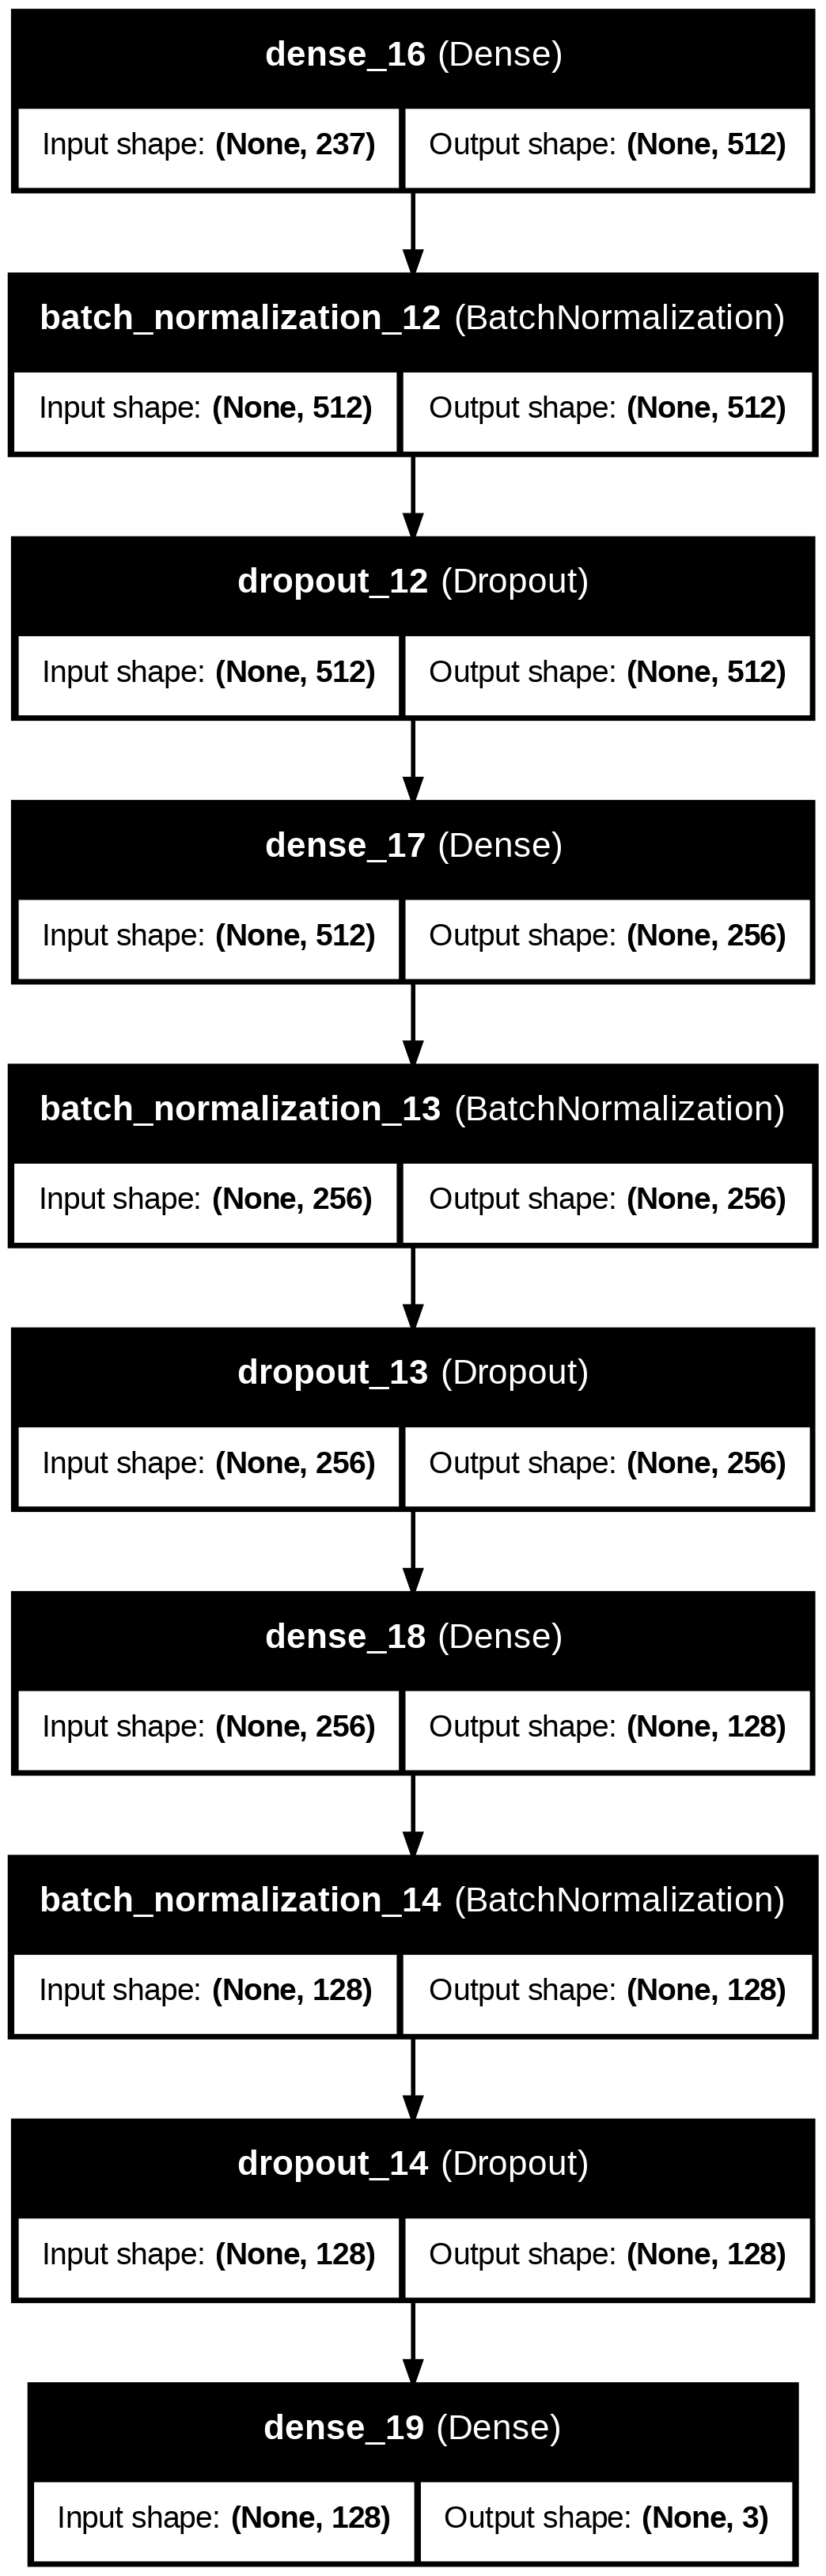

In [54]:
tf.keras.utils.plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

In [55]:
# ## -- MODEL EVALUATION FROM LAST TRAINER --
# print('========= EVALUATE BEST MODEL')
# inference_model_to_eval = tf.keras.models.load_model(f"{CHECKPOINT}infer_model_1.keras")

# # Re-compile the loaded model to enable evaluation
# inference_model_to_eval.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
#     loss='binary_crossentropy',
#     metrics=[
#         tf.keras.metrics.AUC(name='auc')
#     ]
# )

# inference_model_to_eval.evaluate(result['val_data'][0])

In [56]:
# 'submit_keras_V0_[768, 256, 128]97667.csv'

In [57]:
## -- PLOTTING RESULTS --
def plot_results(history, plot_dict=None):
    list_ = list(plot_dict.keys())
    val_loss = 'val_' + plot_dict[list_[0]]
    val_acc  = 'val_' + plot_dict[list_[1]]
    for i, data in tqdm(enumerate(histories), total=len(histories)):
        loss_results = pd.DataFrame({plot_dict[list_[0]]: data[plot_dict[list_[0]]], val_loss: data[val_loss]})
        acc_results = pd.DataFrame({plot_dict[list_[1]]: data[plot_dict[list_[1]]], val_acc: data[val_acc]})
    
        plt.figure(figsize=(18, 5))
        marker = 'o'
    
        ## -- PLOT 1: LOSS --
        plt.subplot(121)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results[plot_dict[list_[0]]], label='train', marker=marker)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results[val_loss], label='valid', marker=marker)
        plt.title(plot_dict[list_[0]], fontweight='semibold')
        plt.xlabel('Epochs')
        plt.ylabel(plot_dict[list_[0]])
    
        ## -- PLOT 2: ACCURACY --
        plt.subplot(122)
        sns.lineplot(acc_results, x=acc_results.index, y=acc_results[plot_dict[list_[1]]], label='train', marker=marker)
        sns.lineplot(acc_results, x=acc_results.index, y=acc_results[val_acc], label='valid', marker=marker)
        plt.title(plot_dict[list_[1]], fontweight='semibold')
        plt.xlabel('Epochs')
        plt.ylabel(plot_dict[list_[1]])
    
        stat_ = f"fold_score: {result['scores'][0][i]:.5f}"
        plt.scatter(x=0, y=0, label=stat_, color='k')
    
        plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold', color='b')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()
        print()

print('Plot function ready')

Plot function ready


  0%|          | 0/5 [00:00<?, ?it/s]

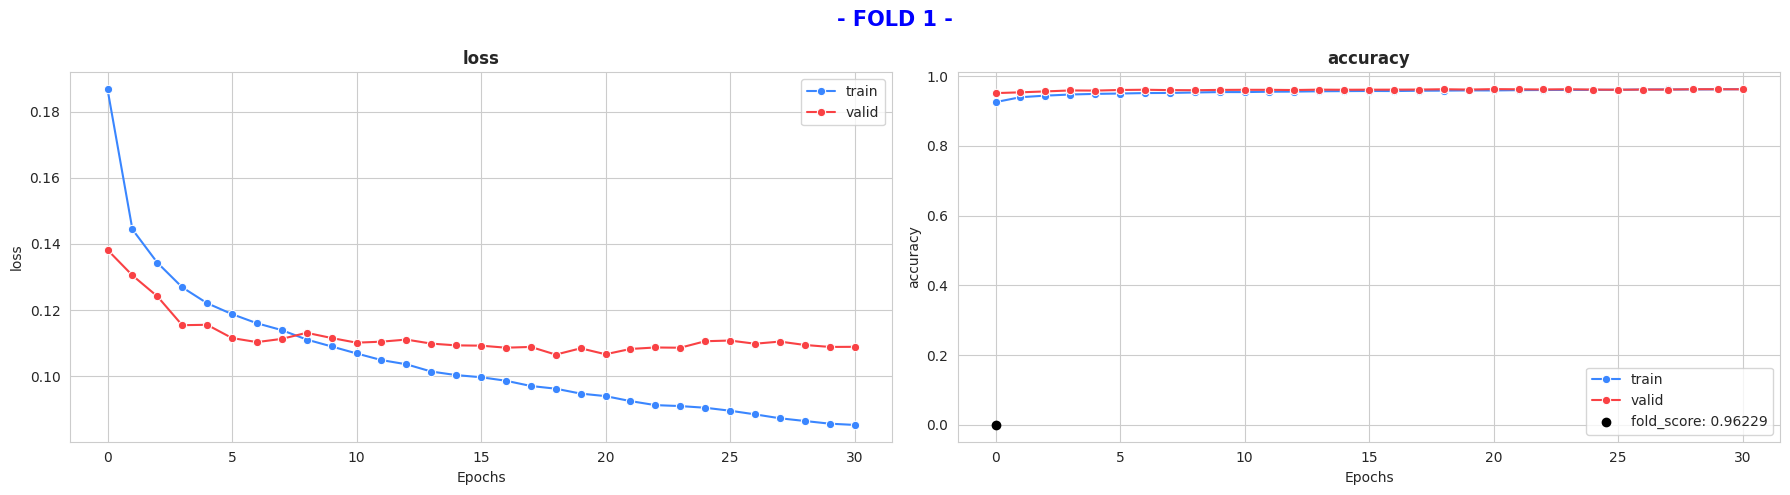

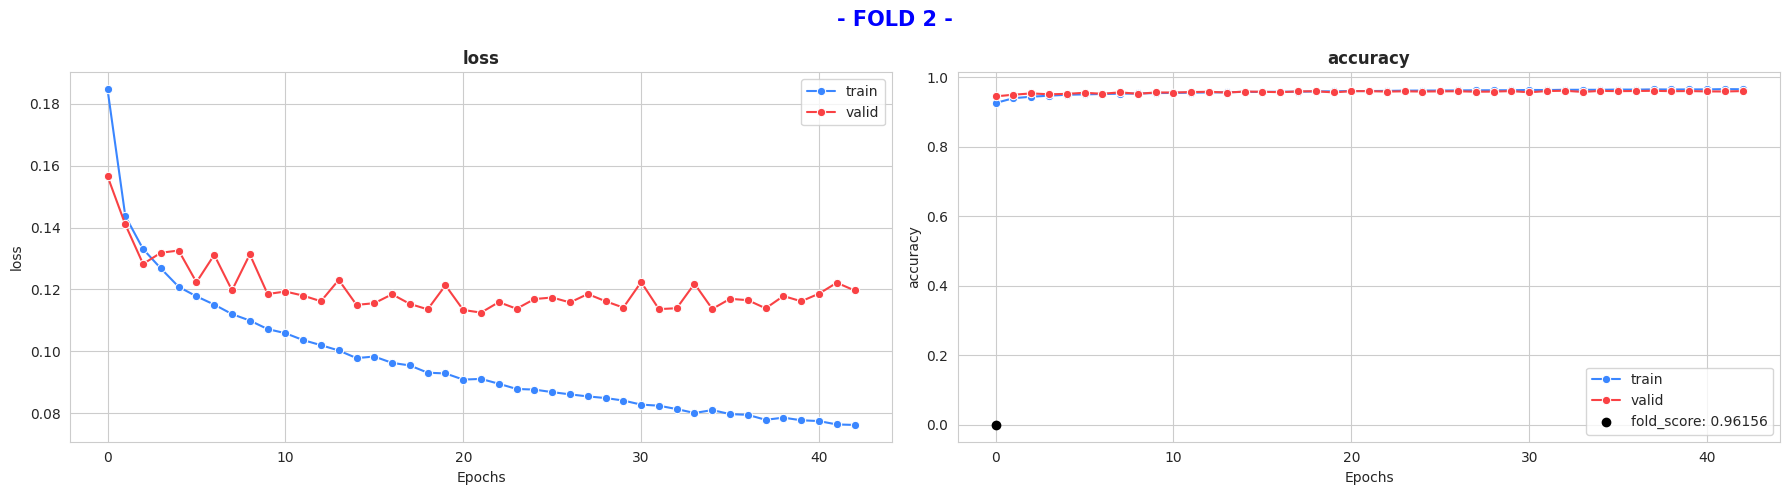

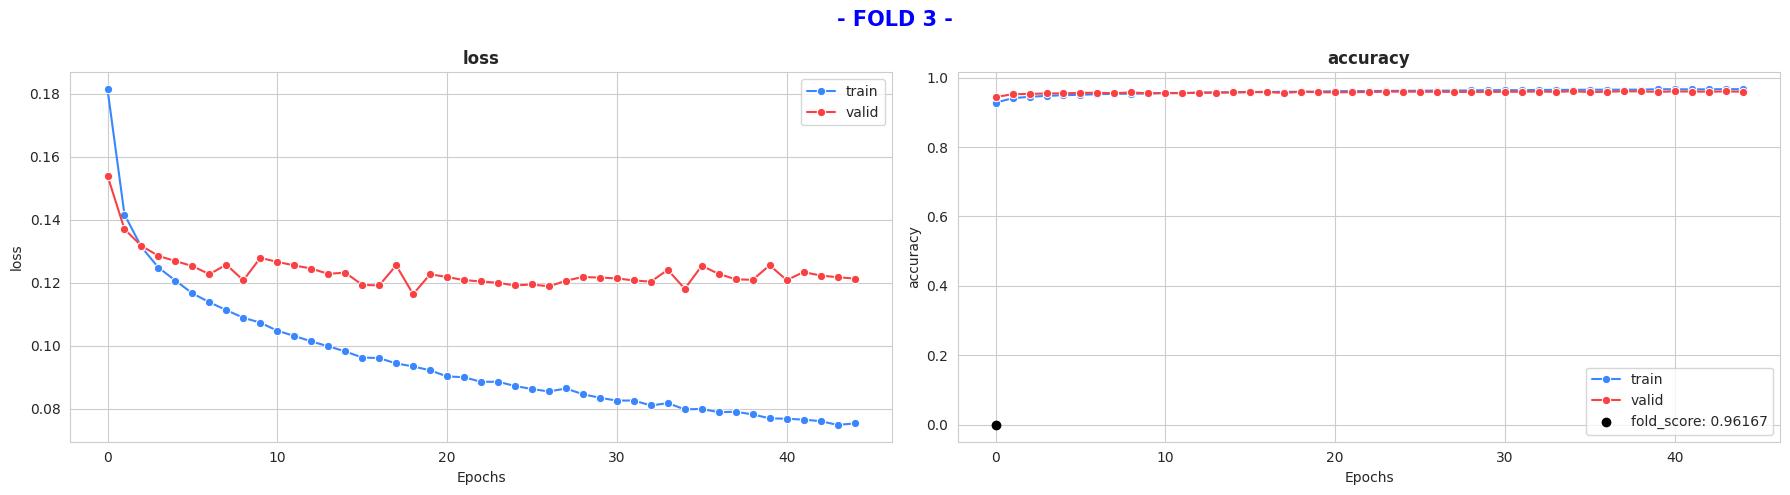

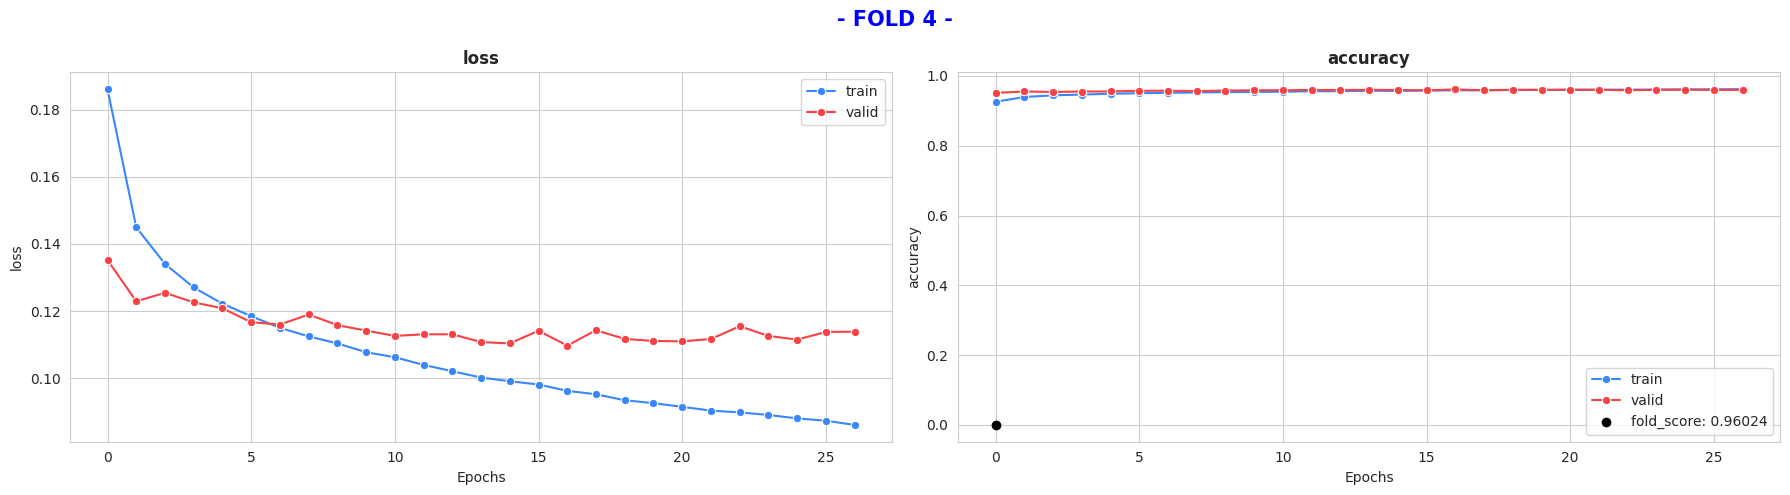

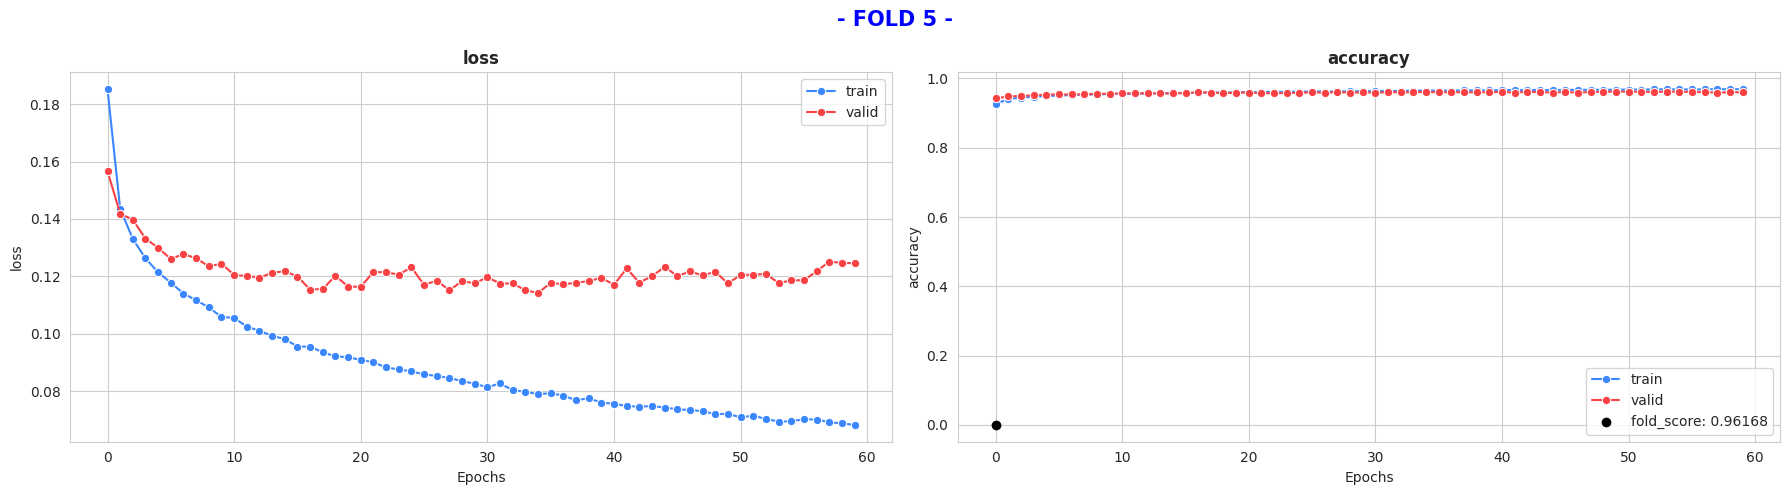

In [58]:
histories = result['history']
plot_dict = {'loss': 'loss', 'acc': 'accuracy'}

plot_results(histories, plot_dict=plot_dict)

In [59]:
## -- Save BASE predictions/submission --
n = version_name + 'base_' + str(result['final_score'][0]).split('.')[1]

np.save(f'oof_{n}.npy', result['oof_preds'][0])
np.save(f'test_{n}.npy', result['test_preds'][0])

file_name = f"submit_{n}.csv"
submit[TARGET] = pd.Series(np.argmax(result['test_preds'][0], axis=1)).map(r_mapping)
submit.to_csv(file_name, index=False)

print(f"Submission file exported as: {file_name}\n")
submit.head(10)

Submission file exported as: submit_scikeras_fe1_base_96149.csv



,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


In [60]:
## -- Save CALIBRATED predictions/submission --
n = version_name + 'calib_' + str(result['final_score'][1]).split('.')[1]

np.save(f'oof_{n}.npy', result['oof_preds'][1])
np.save(f'test_{n}.npy', result['test_preds'][1])

file_name = f"submit_{n}.csv"
submit[TARGET] = pd.Series(np.argmax(result['test_preds'][1], axis=1)).map(r_mapping)
submit.to_csv(file_name, index=False)

print(f"Submission file exported as: {file_name}\n")
submit.head(10)

Submission file exported as: submit_scikeras_fe1_calib_95361.csv



,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


In [61]:
# ## -- PLOTTING RESULTS --
# for i, data in tqdm(enumerate(histories), total=len(histories)):
#     loss_results = pd.DataFrame({'loss': data['loss'], 'val_loss': data['val_loss']})
#     acc_results = pd.DataFrame({'accuracy': data['accuracy'], 'val_accuracy': data['val_accuracy']})

#     plt.figure(figsize=(18, 5))
#     marker = 'o'

#     ## -- PLOT 1: LOSS --
#     plt.subplot(121)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.loss, label='train', marker=marker)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='valid', marker=marker)
#     plt.title('Multi_Loss', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('multi_loss')

#     ## -- PLOT 2: ACCURACY --
#     plt.subplot(122)
#     sns.lineplot(acc_results, x=acc_results.index, y=acc_results.accuracy, label='train', marker=marker)
#     sns.lineplot(acc_results, x=acc_results.index, y=acc_results.val_accuracy, label='valid', marker=marker)
#     plt.title('Balanced_Accuracy', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('balanced_accuracy')

#     stat_ = f"fold_score: {result['scores'][i]:.5f}"
#     plt.scatter(x=0, y=0, label=stat_, color='k')

#     plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold', color='b')
#     plt.legend(loc='best')
#     plt.tight_layout()
#     plt.show()
#     print()